In [1]:
import dipy
import os
import subprocess
import nibabel as nib
import numpy as np
from dipy.core.gradients import gradient_table
from dipy.io.image import load_nifti, save_nifti
from dipy.reconst.dti import TensorModel
from dipy.align.imaffine import AffineMap, MutualInformationMetric, AffineRegistration
from dipy.align.transforms import TranslationTransform3D, RigidTransform3D
import os
import sys
sys.path.append('../../')
from cardpy.Sample_Data.Data_Paths                  import *
from cardpy.Data_Sorting                            import *
from cardpy.Data_Saving                             import *
from cardpy.Data_Processing.Gibbs                   import *
from cardpy.Data_Processing.Registration            import *
from cardpy.Data_Processing.Rejection               import *
from cardpy.Data_Processing.Respiratory             import *
from cardpy.Data_Processing.Diffusivity             import *
from cardpy.Data_Processing.Averaging               import *
from cardpy.Data_Processing.Denoising               import *
from cardpy.Data_Processing.Interpolation           import *
from cardpy.Data_Processing.Segmentation_Matrix_DTI import *
from cardpy.Sample_Data.Data_Paths import *
from cardpy.Data_Import            import *
from cardpy.Data_Sorting           import *
from cardpy.Data_Processing.DTI    import *
from cardpy.Data_Processing.DWI    import *
from cardpy.GUI_Tools              import IntERCOMS
from cardpy.Colormaps              import *
from cardpy.Data_Saving            import *
from cardpy.Data_Processing.cDTI   import *
from cardpy.GUI_Tools                     import *
from cardpy.Colormaps                     import *
# import cardpy
from cardpy.Data_Processing.DTI    import *
from cardpy.GUI_Tools              import IntERCOMS
from cardpy.Colormaps              import *
from matplotlib import pyplot as plt
import os
import subprocess
import nibabel as nib
import numpy as np
import glob
from scipy.io import savemat

import numpy as np
import h5py
from   cardpy.FT_Operators import fft2c, ifft2c 
from cardpy.Data_Import import NifTi_Reader
from matplotlib import pyplot as plt     
from cardpy.Data_Import            import *
from cardpy.Data_Sorting           import *

from dipy.core.histeq import histeq
from dipy.data import get_fnames
from dipy.segment.mask import median_otsu
import os
import nrrd

#smb://171.65.44.79/RSLVA-RAID

/opt/anaconda3/envs/CarDpy3/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import subprocess
import os
import numpy as np

def normalize_complex_image(img_complex, target_value=1000, percentile=95):
    """
    Normalize a complex MRI image using the given percentile of the magnitude,
    then reconstruct the complex image as magnitude * exp(1j * phase).

    Parameters:
        img_complex : np.ndarray
            Coil-combined complex image
        target_value : float
            Desired value for the chosen percentile after scaling
        percentile : float
            Percentile of the magnitude to use for scaling (0-100)

    Returns:
        img_complex_scaled : np.ndarray
            Complex image scaled, phase preserved
        img_mag_scaled : np.ndarray
            Magnitude image ready for DICOM/export
        rescale_slope : float
            Applied scaling factor
    """
    # Compute magnitude and phase
    img_mag = np.abs(img_complex)
    img_phase = np.angle(img_complex)

    # Compute the percentile of the magnitude
    p_val = np.nanpercentile(img_mag, percentile)

    # Compute scaling factor
    rescale_slope = target_value / (p_val + 1e-12)

    # Scale magnitude
    img_mag_scaled = img_mag * rescale_slope

    # Reconstruct complex image
    img_complex_scaled = img_mag_scaled * np.exp(1j * img_phase)

    return img_complex_scaled, img_mag_scaled, rescale_slope

# Example usage:
# img_complex_scaled, img_mag_scaled, slope = normalize_complex_image(img_complex, target_value=1000, percentile=95)
# print("RescaleSlope:", slope)

def bg_phs_removal(data):
    original_matrix = data
    rows                            = original_matrix.shape[0]                                                                      # Extract number of rows
    columns                         = original_matrix.shape[1]                                                                      # Extract number of columns
    slices                          = original_matrix.shape[2]                                                                      # Extract number of slices
    directions                      = original_matrix.shape[3]                                                                      # Extract number of directions
                                                                        # Extract number of averages
    background_phase_removed_matrix = np.zeros(original_matrix.shape)                                                               # Initalize background phased removed matrix
    background_phase_removed_matrix = background_phase_removed_matrix.astype(np.complex128)                                         # Cast background phased removed matrix as complex
    rows_subdivide = int(np.rint(np.nextafter(rows / 8,  rows / 8 + 1)))                                                            # Subdivide rows in to 8ths
    rows_keep      = rows - (rows_subdivide * 2)                                                                                    # Keep ~75% of rows
    pad_rows_num   = rows_subdivide                                                                                                 # Determine number of rows to pad on each side
    cols_subdivide = int(np.rint(np.nextafter(columns / 8,  columns / 8 + 1)))                                                      # Subdivide columns in to 8ths
    cols_keep      = columns - (cols_subdivide * 2)                                                                                 # Keep ~75% of columns
    pad_cols_num   = cols_subdivide                                                                                                 # Determine number of columns to pad on each side
    hamming_filter                  = np.sqrt(np.outer(np.hamming(rows_keep), np.hamming(cols_keep)))                               # Creating hamming filter with
    background_phase_removal_filter = np.pad(hamming_filter, [(pad_rows_num, pad_rows_num), (pad_cols_num, pad_cols_num)])          # Pad with zeros back to original size
    for slc in range(slices):                                                                                                       # Iterate through slices
        for dif in range(directions):                                                                                               # Iterate through diffusion directions
                                                                                                # Iterate through averages
            original_image                 = original_matrix[:, :, slc, dif]                                                       # Store original image from original matrix
            filtered_kspace                = fft2c(original_image) * background_phase_removal_filter                                    # Apply background phase removal filter in k space
            background_phase_removed_image = ifft2c(filtered_kspace)                                                                    # Convert background phase removed k space to image space
            magnitude                      = np.abs(original_image)                                                                     # Store original magnitude data
            phase                          = np.exp(1j * np.angle(original_image))                                                      # Store original phase data
            phase_background_removed       = np.exp(1j * np.angle(background_phase_removed_image))                                      # Store background removed phase data
            background_phase_removed_matrix[:, :, slc, dif] = magnitude * (phase / phase_background_removed)                       # Apply phase background removal to complex data and store
    return background_phase_removed_matrix

In [3]:

# -------------------------------------------------------------------------
# Base paths and configuration
# -------------------------------------------------------------------------

main_path = '/Volumes/T7/Stim-CODE/NifTi/'
volunteers =  ['Phantom_DWI']

#volunteers = ['V003']             
mode = 'Phantom'

volunteer = volunteers[0]
data_folders = [
    #'ep2d_diff_m0_ext_b1000_sos_mmt0',#ep2d_diff_m0_ext_b1000_sos_mmt0/',
    'trap_mmt0_Ncalib2',#'trap_re_mmt0_Ncalib2/',
    'gropt_mmt0_Ncalib2',#'gropt_re_mmt0_Ncalib2/',
    'trap_mmt1_Ncalib2',#'trap_re_mmt0_Ncalib2/',
    'gropt_mmt1_Ncalib2',#'gropt_re_mmt1_Ncalib2/',
]

mask_name = 'eddy_mask' # mask is the isocenter mask

process_folder = '03_Averaged'
process_file = 'Averaged'

phantom_name = volunteers[0]

# Column labels
col_labels = ['Mono', 'Stim-CODE-M$_0$', 'Bipolar', 'Stim-CODE-M$_1$',]



Processing volunteer: Phantom_DWI
Found 1 masks: ['eddy_mask.nrrd']

--- Scan: trap_mmt0_Ncalib2 ---
(146, 146, 1, 4)
(146, 146, 1, 3)
7
(146, 146, 1, 3) (146, 146) (146, 146)
(146, 146, 1)
(146, 146, 1)


/var/folders/mb/68q17fnn0sbfmdht6h_p8mlw0000gn/T/ipykernel_51206/424242832.py:177: RuntimeWarning: Mean of empty slice
  np.nanmean(mat_sorted * mask_inner[:,:,np.newaxis,np.newaxis], axis=-1)
/var/folders/mb/68q17fnn0sbfmdht6h_p8mlw0000gn/T/ipykernel_51206/424242832.py:183: RuntimeWarning: Mean of empty slice
  np.nanmean(mat_sorted * mask_to_use[:,:,np.newaxis,:], axis=-1)


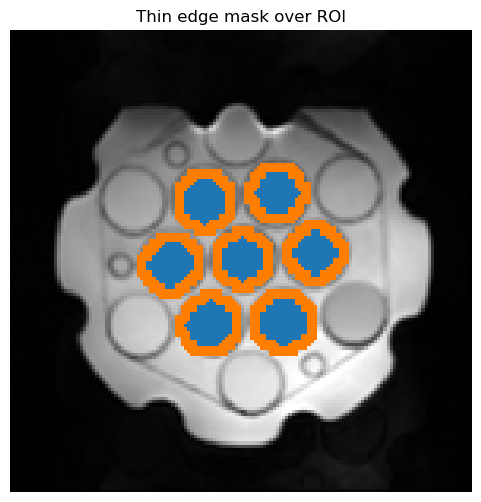

(146, 146, 1, 3) (146, 146)


/var/folders/mb/68q17fnn0sbfmdht6h_p8mlw0000gn/T/ipykernel_51206/424242832.py:212: RuntimeWarning: Mean of empty slice
  np.nanmean(mat_sorted * thin_edge_mask[:,:,np.newaxis,np.newaxis], axis=-1)


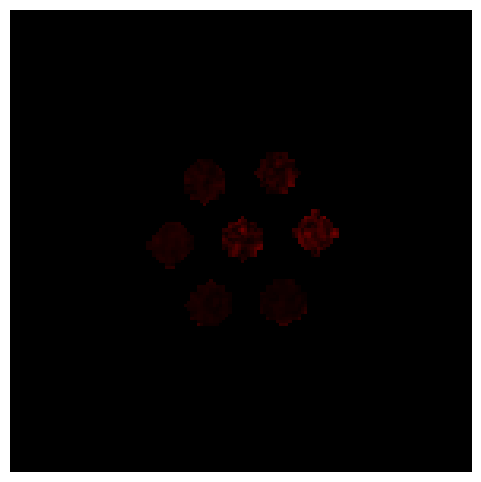

%CoV (Whole): 1.30% | %CoV (Edge): 3.40%

--- Scan: gropt_mmt0_Ncalib2 ---
(146, 146, 1, 4)
(146, 146, 1, 3)
7
(146, 146, 1, 3) (146, 146) (146, 146)
(146, 146, 1)
(146, 146, 1)


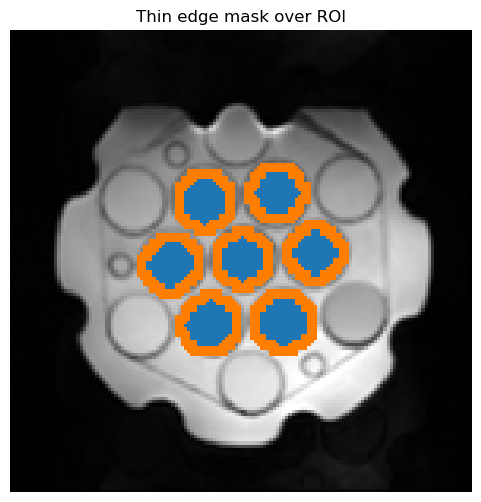

(146, 146, 1, 3) (146, 146)


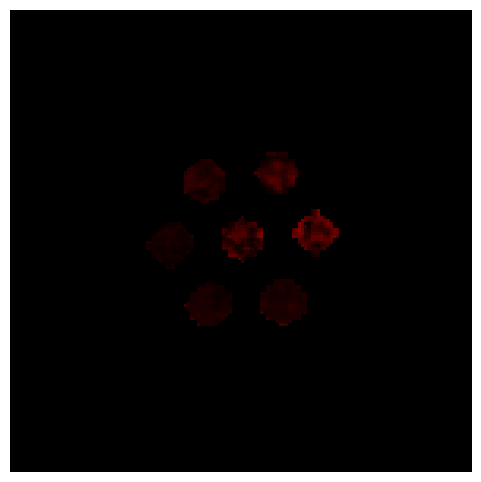

%CoV (Whole): 1.56% | %CoV (Edge): 3.64%

--- Scan: trap_mmt1_Ncalib2 ---
(146, 146, 1, 4)
(146, 146, 1, 3)
7
(146, 146, 1, 3) (146, 146) (146, 146)
(146, 146, 1)
(146, 146, 1)


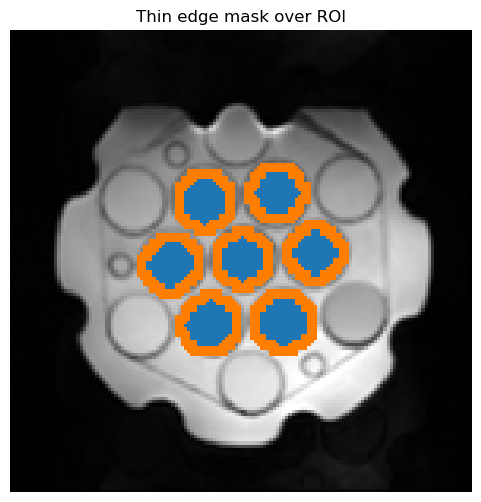

(146, 146, 1, 3) (146, 146)


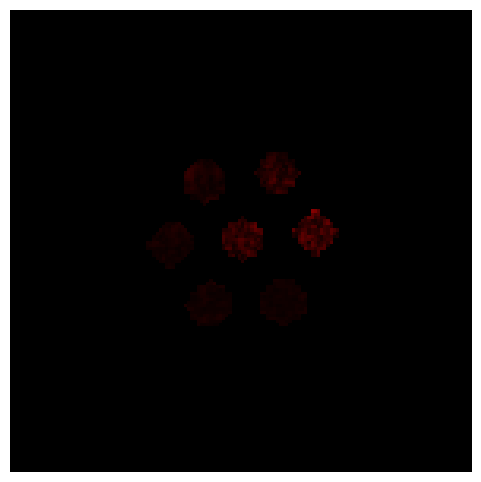

%CoV (Whole): 1.17% | %CoV (Edge): 1.99%

--- Scan: gropt_mmt1_Ncalib2 ---
(146, 146, 1, 4)
(146, 146, 1, 3)
7
(146, 146, 1, 3) (146, 146) (146, 146)
(146, 146, 1)
(146, 146, 1)


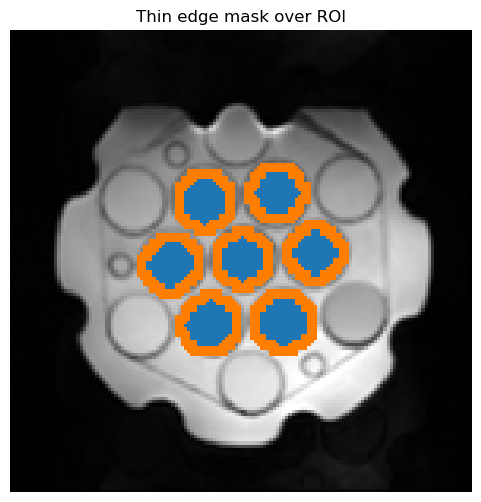

(146, 146, 1, 3) (146, 146)


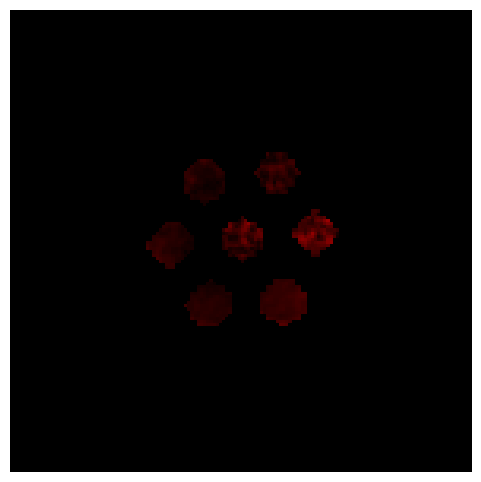

%CoV (Whole): 2.76% | %CoV (Edge): 3.99%


In [32]:
# -------------------------------------------------------------------------
# Storage containers
# -------------------------------------------------------------------------
data_all_vols = {}
mask_all_vols = {}            # selected mask per scan
maskbank_all_vols = {}        # all masks per volunteer
median_cov_all_vols = {}      # store %CoV in whole mask
median_cov_edge_all_vols = {} # store %CoV at edges
cov_whole_maps_all_vols = {}

# -------------------------------------------------------------------------
# Loop over volunteers
# -------------------------------------------------------------------------
for volunteer in volunteers:
    
    print(f"\n============================")
    print(f"Processing volunteer: {volunteer}")
    print(f"============================")

    data_all_vols[volunteer] = []
    mask_all_vols[volunteer] = []

    maskbank_all_vols[volunteer] = {}
    median_cov_all_vols[volunteer] = []
    median_cov_edge_all_vols[volunteer] = []
    cov_whole_maps_all_vols[volunteer] = []
    scan_names_all_vols = []

    # ---------------------------------------------------------
    # 🔍 Auto-search for all masks in volunteer directory
    # ---------------------------------------------------------
    volpath = os.path.join(main_path, volunteer)
    mask_files = [
        f for f in os.listdir(volpath)
        if f.endswith(".nrrd") and not f.startswith("._")
        and "eddy" in f.lower()
    ]
    print(f"Found {len(mask_files)} masks: {mask_files}")

    # ---------------------------------------------------------
    # 📥 Load all masks
    # ---------------------------------------------------------
    for mf in mask_files:
        mpath = os.path.join(volpath, mf)
        mask_arr = nrrd.read(mpath)[0].astype('float32')
        mask_arr[mask_arr == 0] = np.nan
        mask_arr = np.flip(mask_arr, axis=0)
        mask_name_clean = os.path.splitext(mf)[0]
        maskbank_all_vols[volunteer][mask_name_clean] = mask_arr

    # ---------------------------------------------------------
    # Loop over scans
    # ---------------------------------------------------------
    for folder in data_folders:
        print(f"\n--- Scan: {folder} ---")
        base_path = os.path.join(main_path, volunteer, folder)

        NifTi_path = os.path.join(base_path, process_folder, process_file + '.nii')
        b_values_path = os.path.join(base_path, process_folder, process_file + '.bvals')
        b_vectors_path = os.path.join(base_path, process_folder, process_file + '.bvecs')
        header_path = os.path.join(base_path, process_folder, process_file + '.header')

        if not all(os.path.exists(p) for p in [NifTi_path, b_values_path, b_vectors_path]):
            print(f"⚠️ Missing files for {folder}. Skipping.")
            continue

        # ---------------------------------------------
        # Load + process DWI
        # ---------------------------------------------
        [mat_stack, bvals_stack, bvecs_stack,
         Header, voxel_resolution, affine_matrix] = NifTi_Reader(
            NifTi_path, b_values_path, b_vectors_path, header_path, info='OFF'
        )

        tmp_norm, _, _ = normalize_complex_image(mat_stack, target_value=1000)
        tmp_bg_phs = np.real(bg_phs_removal(tmp_norm))
        [mat_sorted, bvals_sorted, bvecs_sorted] = stacked2sorted(
            tmp_bg_phs, bvals_stack, bvecs_stack
        )
        mat_sorted = np.flip(mat_sorted, axis=(0))[...,0]  # single volume per scan
        

        # ---------------------------------------------
        # Store DWI
        # ---------------------------------------------
        print(mat_sorted.shape)
        data_all_vols[volunteer].append(mat_sorted)
        mat_sorted = mat_sorted[:,:,:,1:]
        print(mat_sorted.shape)

        # ---------------------------------------------
        # Pick mask (first one in bank for now)
        # ---------------------------------------------
        mask_to_use = maskbank_all_vols[volunteer][mask_name]
        mask_to_use = mask_to_use.astype('float')
        mask_to_use[mask_to_use == 0] = np.nan

        

        from skimage import measure
        from scipy.ndimage import label

        # -------------------------------
        # Edge mask %CoV (thin edges of each circle)
        # -------------------------------
        from skimage import measure
        from scipy.ndimage import label

        # -------------------------------
        # Edge mask %CoV (thin edges of each circle)
        # -------------------------------
        mask_filled = np.nan_to_num(mask_to_use, nan=0)[:,:,0]

        # Label connected components (each circle)
        labeled_mask, n_labels = label(mask_filled)

        print(n_labels)

        # Initialize thin edge mask
        thin_edge_mask = np.zeros_like(mask_filled, dtype=float)

        for i_label in range(1, n_labels + 1):
            component = (labeled_mask == i_label).astype(float)
            # Find contours of this component
            contours = measure.find_contours(component, level=0.5)
            for contour in contours:
                # Round contour coordinates to nearest integer and draw them in the mask
                for y, x in np.round(contour).astype(int):
                    if 0 <= y < thin_edge_mask.shape[0] and 0 <= x < thin_edge_mask.shape[1]:
                        thin_edge_mask[y, x] = 1

        # Initialize thin edge mask
        thin_edge_mask = np.zeros_like(mask_filled, dtype=float)

        for i_label in range(1, n_labels + 1):
            component = (labeled_mask == i_label).astype(float)
            # Find contours of this component
            contours = measure.find_contours(component, level=0.5)
            for contour in contours:
                # Round contour coordinates to nearest integer
                contour_pixels = np.round(contour).astype(int)
                for y, x in contour_pixels:
                    if 0 <= y < thin_edge_mask.shape[0] and 0 <= x < thin_edge_mask.shape[1]:
                        thin_edge_mask[y, x] = 1

            # ---- new part: include two pixels inward from each edge pixel ----
            # This keeps the same edge thickness but captures more of the interior
            edge_coords = np.argwhere(thin_edge_mask == 1)

            for y, x in edge_coords:
                for dy in [-2, -1, 0, 1, 2]:
                    for dx in [-2, -1, 0, 1, 2]:
                        ny, nx = y + dy, x + dx
                        if 0 <= ny < thin_edge_mask.shape[0] and 0 <= nx < thin_edge_mask.shape[1]:
                            if component[ny, nx] == 1:  # only include interior pixels
                                thin_edge_mask[ny, nx] = 1

        # Convert zeros to NaN
        thin_edge_mask[thin_edge_mask == 0] = np.nan

                    

        # Convert zeros to NaN for masking
        thin_edge_mask[thin_edge_mask == 0] = np.nan
        # -------------------------------
        # Whole mask %CoV
        # -------------------------------
        # ---------------------------------------------------------
        # Exclude edge from whole mask (INTERIOR ONLY)
        # ---------------------------------------------------------
        
        mask_inner = mask_to_use[:,:,0].copy()
        mask_inner[~np.isnan(thin_edge_mask)] = 0
        mask_inner[mask_inner == 0] = np.nan
        print(mat_sorted.shape,mask_inner.shape,thin_edge_mask.shape)
        cov_whole = 100 * np.nanstd(mat_sorted * mask_inner[:,:,np.newaxis,np.newaxis], axis=-1) / \
                    np.nanmean(mat_sorted * mask_inner[:,:,np.newaxis,np.newaxis], axis=-1)
        print(cov_whole.shape)
        median_cov_whole = np.nanmedian(cov_whole * mask_inner)
        median_cov_all_vols[volunteer].append(median_cov_whole)

        tmp = 100 * np.nanstd(mat_sorted * mask_to_use[:,:,np.newaxis,:], axis=-1) / \
                    np.nanmean(mat_sorted * mask_to_use[:,:,np.newaxis,:], axis=-1)
        print(tmp.shape)
        cov_whole_maps_all_vols[volunteer].append(tmp[:,:,0])
        scan_names_all_vols.append(folder)

        # Optional visualization
        fig,axs = plt.subplots(figsize=(6,6))
        axs.imshow(data_all_vols[volunteer][0][:,:,0,0],cmap ='gray',vmin =0 ,vmax = 1500)
        import matplotlib.colors as mcolors

        from matplotlib.colors import ListedColormap

        # Convert your barplot colors to a colormap
        cmap_whole = ListedColormap([[0.121, 0.467, 0.706, 1]])  # #1f77b4 with alpha=0.5
        cmap_edge  = ListedColormap([[1.0, 0.498, 0.0, 1]])      # #ff7f0e with alpha=0.5

        # Overlay masks
        axs.imshow(mask_to_use, cmap=cmap_whole, alpha=1)
        axs.imshow(thin_edge_mask, cmap=cmap_edge, alpha=1)
        axs.set_title("Thin edge mask over ROI")
        axs.axis('off')
        plt.show()
        fig.savefig(f'Cov_Mask_{folder}.svg',dpi=100,bbox_inches='tight')


        
        # Compute edge %CoV
        print(mat_sorted.shape,thin_edge_mask.shape)
        cov_edge = 100 * np.nanstd(mat_sorted * thin_edge_mask[:,:,np.newaxis,np.newaxis], axis=-1) / \
                np.nanmean(mat_sorted * thin_edge_mask[:,:,np.newaxis,np.newaxis], axis=-1)
        median_cov_edge = np.nanmedian(cov_edge * thin_edge_mask)
        median_cov_edge_all_vols[volunteer].append(median_cov_edge)
        # Store selected mask
        mask_all_vols[volunteer].append(mask_to_use)

        # show cov 
        fig,axs = plt.subplots(figsize=(6,6))
        axs.imshow(np.zeros(cov_whole[:,:,0].shape),cmap ='gray',vmin =0 ,vmax = 1500)
        axs.imshow(cov_whole[:,:,0],cmap ='hot',vmin =0 ,vmax = 50  )
        axs.axis('off')
        plt.show()
        fig.savefig(f'Cov_Whole_{folder}.svg',dpi=100,bbox_inches='tight')

        print(f"%CoV (Whole): {median_cov_whole:.2f}% | %CoV (Edge): {median_cov_edge:.2f}%")

/var/folders/mb/68q17fnn0sbfmdht6h_p8mlw0000gn/T/ipykernel_51206/2671558151.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


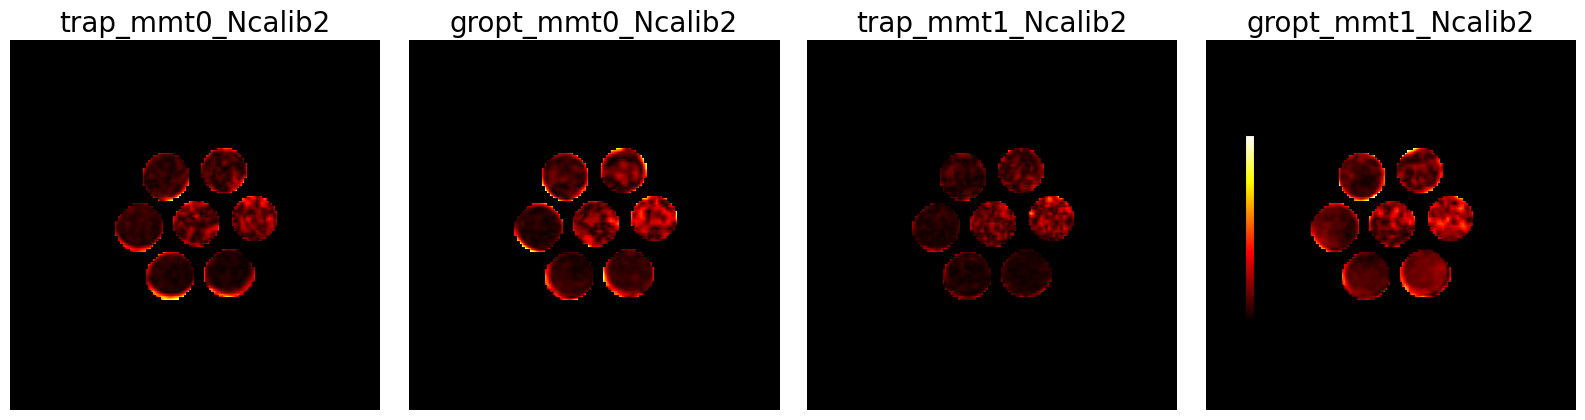

In [28]:
# ---------------------------------------------------------
# Plot CoV_whole for all scans in a row
# ---------------------------------------------------------
n_scans = len(cov_whole_maps_all_vols[volunteer])

fig, axes = plt.subplots(
    1, n_scans,
    figsize=(4 * n_scans, 4),
    squeeze=False
)



for i, ax in enumerate(axes[0]):
    ax.imshow(np.zeros(cov_whole_maps_all_vols[volunteer][i].shape),cmap ='gray',vmin =0 ,vmax = 1500)
    im = ax.imshow(
        cov_whole_maps_all_vols[volunteer][i],
        cmap='hot',
        vmin=0,
        vmax=20
    )
    ax.set_title(scan_names_all_vols[i], fontsize=20)
    ax.axis('off')

# add colorbar to right while keeping subplot spacing and proportion
cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    shrink=0.6,
    location='right',
    pad=0.02
)
plt.tight_layout()
plt.show()
fig.savefig(f'Cov_Whole_AllScans_Row_{volunteer}.svg',dpi=100,bbox_inches='tight')


=== Plotting stacked %CoV for Phantom_DWI ===


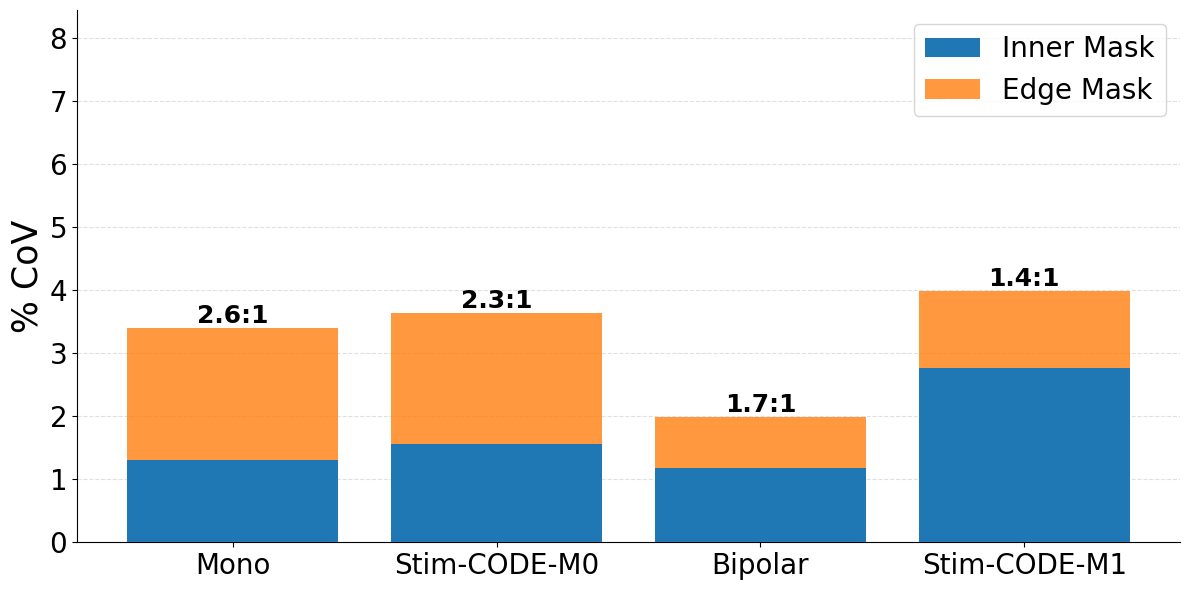

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------
# Settings
# ------------------------
colors = ['#1f77b4', '#ff7f0e']  # blue=whole, orange=edge
title_fs = 20
ylabel_fs = 25
tick_fs = 20
bar_alpha = 0.8

# ------------------------
# Loop over volunteers
# ------------------------
for volunteer in volunteers:
    print(f"\n=== Plotting stacked %CoV for {volunteer} ===")

    scans = data_folders
    n_scans = len(scans)

    whole_cov = np.array(median_cov_all_vols[volunteer])
    edge_cov  = np.array(median_cov_edge_all_vols[volunteer])

    ratio = edge_cov / whole_cov  # <-- ratio edge : whole

    x = np.arange(n_scans)

    fig, ax = plt.subplots(figsize=(3 * n_scans, 6))

    # Stacked bars
    ax.bar(x, whole_cov, bottom = 0,color=colors[0], alpha=1, label='Inner Mask',zorder = 3)
    ax.bar(x, edge_cov, bottom=0, color=colors[1],
           alpha=bar_alpha, label='Edge Mask', zorder=2)

    # Labels and formatting
    ax.set_xticks(x)
    ax.set_ylabel('% CoV', fontsize=ylabel_fs)
    ax.legend(fontsize=tick_fs)
    ax.set_ylim(0, np.max(whole_cov + edge_cov) * 1.25)

    # Spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=tick_fs)

    # Custom xticks
    tick_names = ['Mono', 'Stim-CODE-M0', 'Bipolar', 'Stim-CODE-M1']
    ax.set_xticklabels(tick_names, rotation=0, fontsize=tick_fs)
    
    # ylines grid light
    ax.yaxis.grid(True, linestyle='--', which='major', color='lightgrey', alpha=0.7,zorder = 0)

    # ------------------------
    # Add ratio text
    # ------------------------
    for i in range(n_scans):
        y_top =  edge_cov[i]
        ax.text(
            x[i],
            y_top * 1.0,
            f'{ratio[i]:.1f}:1',
            ha='center',
            va='bottom',
            fontsize=18, fontweight ='bold'
        )

    plt.tight_layout()
    plt.show()
    fig.savefig(f'fig_cov_stacked_{volunteer}.svg',
                dpi=300, bbox_inches='tight')


=== Plotting volunteer: Phantom_DWI ===


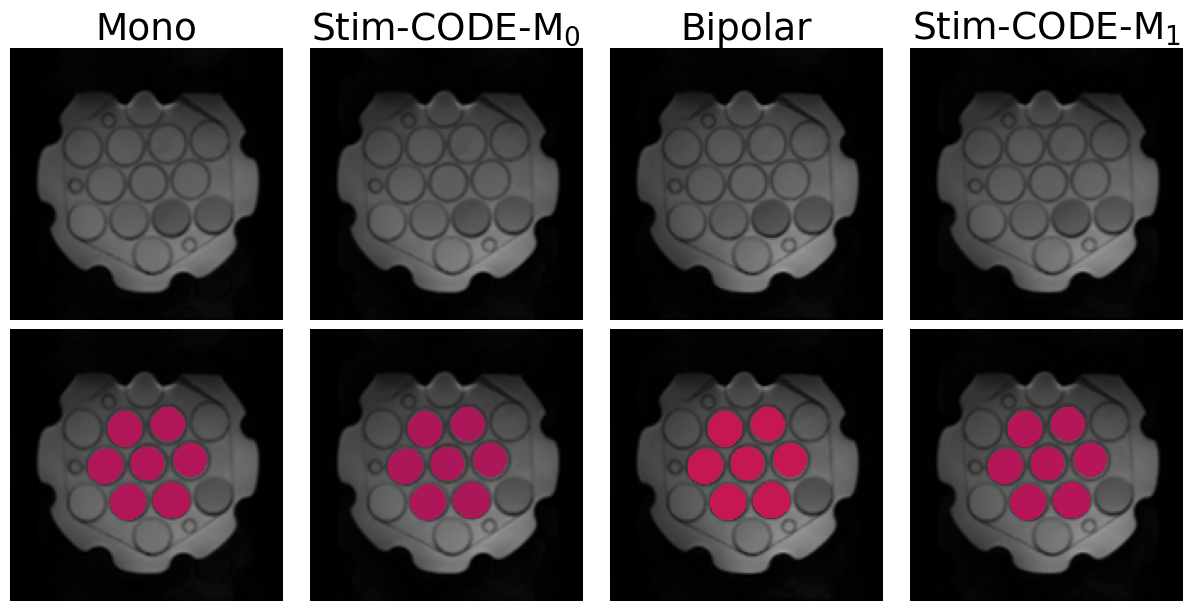

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import Normalize
mpl.rcParams['axes.labelweight'] = 'normal'
mpl.rcParams['axes.titleweight'] = 'normal'

rocket_cmap = sns.color_palette("rocket", as_cmap=True)

# ------------------------
# Settings
# ------------------------
plot_slices = {v: 0 for v in volunteers}  # slice index to plot
scans_to_plot = data_folders

# Font sizes
title_fs = 27
ylabel_fs = 28
tick_fs = 18

# Color scale limits for CoV
cov_vmin, cov_vmax = 0, 30  # typical %CoV range
dwi_vmin, dwi_vmax = 0, 3000

# ------------------------
# Loop over volunteers
# ------------------------
for volunteer in volunteers:
    print(f"\n=== Plotting volunteer: {volunteer} ===")
    
    slice_idx = plot_slices[volunteer]
    n_rows = 2  # Top: DWI, Bottom: DWI + CoV overlays
    n_cols = len(scans_to_plot)
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 6), constrained_layout=True)
    
    if n_rows == 1:
        axs = np.array(axs).reshape(1, n_cols)
    if n_cols == 1:
        axs = axs[:, np.newaxis]

    # Colormap for mask overlays
    mask_colors = sns.color_palette("Set2", len(maskbank_all_vols[volunteer]))

    for col_idx, folder in enumerate(scans_to_plot):
        try:
            idx_folder = data_folders.index(folder)
        except ValueError:
            print(f"⚠️ Folder {folder} not found for {volunteer}, skipping")
            continue

        # Base DWI slice (top row) — take 0-th index of last dimension
        data = data_all_vols[volunteer][idx_folder]
        dwi_img = np.real(data[:, :, slice_idx, 0])  # <- take 0-th index of last dimension
        axs[0, col_idx].imshow(dwi_img, cmap='gray', vmin=dwi_vmin, vmax=dwi_vmax)
        axs[0, col_idx].set_title(col_labels[col_idx], fontsize=title_fs)
        axs[0, col_idx].axis('off')

        # Bottom row: DWI with all masks overlayed by %CoV
        axs[1, col_idx].imshow(dwi_img, cmap='gray', vmin=dwi_vmin, vmax=dwi_vmax)

        # Overlay each mask with its %CoV
        
        for m_idx, (mask_name, mask_arr) in enumerate(maskbank_all_vols[volunteer].items()):
            mask_slice = mask_arr[:, :, slice_idx].copy()
            mask_slice[mask_slice == 0] = np.nan

            # Compute %CoV directly from slice (no averaging)
            masked_data = data[:, :, slice_idx, 0] * mask_slice
            cov_slice = 100 * np.nanstd(masked_data) / np.nanmean(masked_data)

            # Create overlay array
            overlay = np.full(mask_slice.shape, cov_slice)
            overlay[np.isnan(mask_slice)] = np.nan  # keep NaN outside mask

            axs[1, col_idx].imshow(overlay, cmap=rocket_cmap,
                                   alpha=1, vmin=cov_vmin, vmax=cov_vmax)

        axs[1, col_idx].axis('off')

    plt.show()
    fig.savefig(f'fig_cov_{volunteer}.svg', dpi=300, bbox_inches='tight')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
#  GLOBAL FONT + STYLE CONTROL
# ====================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 30
TICK_FONTSIZE  = 25
SCATTER_SIZE   = 18

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# ====================================================
# User choices
# ====================================================

jitter       = 0.12

scan_names = data_folders
mask_names = list(maskbank_all_vols[phantom_name].keys())

palette = sns.color_palette("tab10", len(mask_names))

# ====================================================
# Pre-collect voxel-wise SNR data
# ====================================================
# Stores per scan, per mask, all voxel SNRs for both directions
phantom_snr = {scan: {} for scan in scan_names}

for s, scan in enumerate(scan_names):

    # Load SNR maps for this scan
    snr_map_vol = snr_all_vols[phantom_name][s]  # shape: (X,Y,Z,2) or (..., dirs)
    
    for mask_name in mask_names:
        mask = maskbank_all_vols[phantom_name][mask_name]

        # Direction 0
        snr_dir0 = snr_map_vol[..., 0] * mask
        snr_dir0 = snr_dir0[np.isfinite(snr_dir0) & (snr_dir0 > 0)]
        
        # Direction 1
        snr_dir1 = snr_map_vol[..., 1] * mask
        snr_dir1 = snr_dir1[np.isfinite(snr_dir1) & (snr_dir1 > 0)]

        # Store
        phantom_snr[scan][mask_name] = {
            'dir0': snr_dir0,
            'dir1': snr_dir1
        }

        print(f"{scan:18s} | {mask_name:15s} | "
              f"SNR Dir0: {snr_dir0.size:7d} | SNR Dir1: {snr_dir1.size:7d}")

NameError: name 'snr_all_vols' is not defined

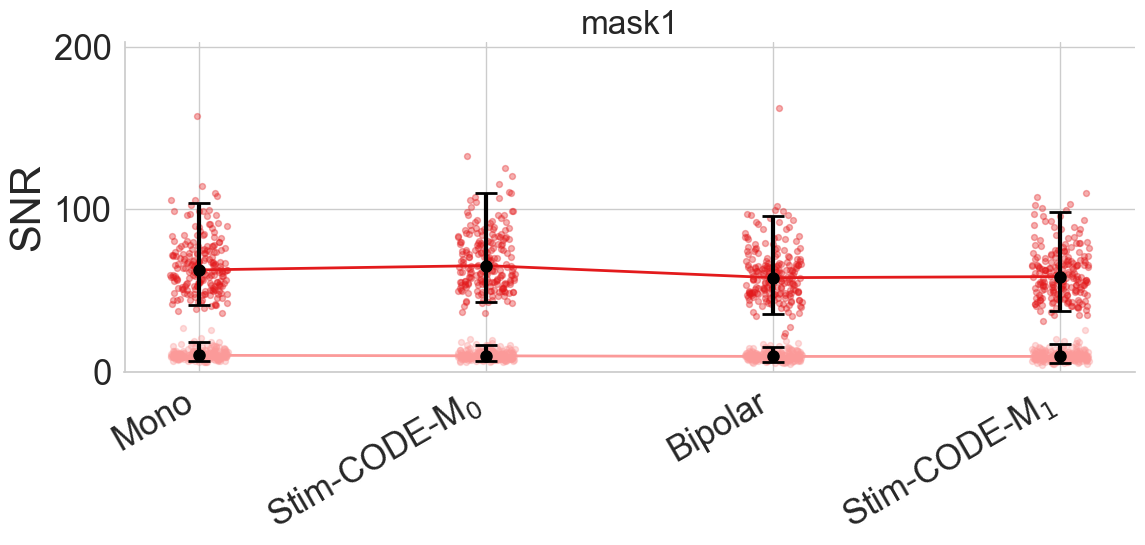

trap_mmt0_Ncalib2  | Dir0 Median SNR:  62.76 (95% CI:  41.04 - 103.93) | Dir1 Median SNR:  10.22 (95% CI:   6.68 -  18.11)
gropt_mmt0_Ncalib2 | Dir0 Median SNR:  65.42 (95% CI:  42.93 - 109.89) | Dir1 Median SNR:   9.90 (95% CI:   6.58 -  16.70)
trap_mmt1_Ncalib2  | Dir0 Median SNR:  58.00 (95% CI:  35.91 -  96.23) | Dir1 Median SNR:   9.53 (95% CI:   5.90 -  15.48)
gropt_mmt1_Ncalib2 | Dir0 Median SNR:  58.67 (95% CI:  37.56 -  98.50) | Dir1 Median SNR:   9.55 (95% CI:   5.61 -  17.46)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
# GLOBAL FONT + STYLE CONTROL
# ====================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 30
TICK_FONTSIZE  = 25
SCATTER_SIZE   = 18
DOT_SIZE       = 8
ERROR_LW       = 3.0
CAPSIZE        = 8
CAPTHICK       = 2
JITTER         = 0.10

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# ====================================================
# USER CHOICES
# ====================================================
mask_to_plot = 'mask1'   # <-- choose single mask here


scan_xtick_labels = [
    'Mono', 'Stim-CODE-M$_0$', 'Bipolar', 'Stim-CODE-M$_1$'
]

DIR0_COLOR = sns.color_palette('Paired', 10)[5]
DIR1_COLOR = sns.color_palette('Paired', 10)[4]

xpos = np.arange(len(scan_names))

# ============================================================
# Bootstrap CI function
# ============================================================
def bootstrap_ci(data):
    data = np.array(data)
    N    = data.shape[0]
    Nbs  = 1000

    np.random.seed(0)
    bs_idx = np.random.randint(0, N, (N, Nbs))
    bs     = data[bs_idx]

    lo = np.percentile(bs, 2.5, axis=0).mean()
    hi = np.percentile(bs, 97.5, axis=0).mean()

    return np.nanmedian(data), lo, hi

# ====================================================
# Plot
# ====================================================
fig, ax = plt.subplots(figsize=(12, 6))

dir0_medians = []
dir1_medians = []

for s, scan in enumerate(scan_names):

    # --------------------------
    # Direction 0
    # --------------------------
    snr_dir0 = phantom_snr[scan][mask_to_plot]['dir0']
    ax.scatter(
        np.full_like(snr_dir0, xpos[s]) +
        np.random.uniform(-JITTER, JITTER, len(snr_dir0)),
        snr_dir0,
        s=SCATTER_SIZE,
        alpha=0.35,
        color=DIR0_COLOR
    )

    med0, lo0, hi0 = bootstrap_ci(snr_dir0)
    dir0_medians.append(med0)

    ax.errorbar(
        xpos[s], med0,
        yerr=[[med0 - lo0], [hi0 - med0]],
        fmt='o', color='black',
        lw=ERROR_LW, markersize=DOT_SIZE,
        capsize=CAPSIZE, capthick=CAPTHICK, zorder=10
    )

    # --------------------------
    # Direction 1
    # --------------------------
    snr_dir1 = phantom_snr[scan][mask_to_plot]['dir1']
    ax.scatter(
        np.full_like(snr_dir1, xpos[s]) +
        np.random.uniform(-JITTER, JITTER, len(snr_dir1)),
        snr_dir1,
        s=SCATTER_SIZE,
        alpha=0.35,
        color=DIR1_COLOR
    )

    med1, lo1, hi1 = bootstrap_ci(snr_dir1)
    dir1_medians.append(med1)

    ax.errorbar(
        xpos[s], med1,
        yerr=[[med1 - lo1], [hi1 - med1]],
        fmt='o', color='black',
        lw=ERROR_LW, markersize=DOT_SIZE,
        capsize=CAPSIZE, capthick=CAPTHICK, zorder=10
    )

# --------------------------
# Connect medians
# --------------------------
ax.plot(xpos, dir0_medians, color=DIR0_COLOR, lw=2)
ax.plot(xpos, dir1_medians, color=DIR1_COLOR, lw=2)

# --------------------------
# Axis formatting
# --------------------------
ax.set_xticks(xpos)
ax.set_xticklabels(scan_xtick_labels, rotation=30, ha='right')
ax.set_ylabel('SNR')
ax.set_title(mask_to_plot)

ax.set_ylim(
    0,
    3.1 * np.nanmax(
        [np.nanmax(dir0_medians), np.nanmax(dir1_medians)]
    )
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

fig.savefig(
    f'Fig_SNR_dir0_dir1_{mask_to_plot}_{phantom_name}.svg',
    dpi=300,
    bbox_inches='tight'
)

# Print median and 95% CI values
for s, scan in enumerate(scan_names):
    snr_dir0 = phantom_snr[scan][mask_to_plot]['dir0']
    med0, lo0, hi0 = bootstrap_ci(snr_dir0)

    snr_dir1 = phantom_snr[scan][mask_to_plot]['dir1']
    med1, lo1, hi1 = bootstrap_ci(snr_dir1)

    print(f"{scan:18s} | "
          f"Dir0 Median SNR: {med0:6.2f} (95% CI: {lo0:6.2f} - {hi0:6.2f}) | "
          f"Dir1 Median SNR: {med1:6.2f} (95% CI: {lo1:6.2f} - {hi1:6.2f})"
    )

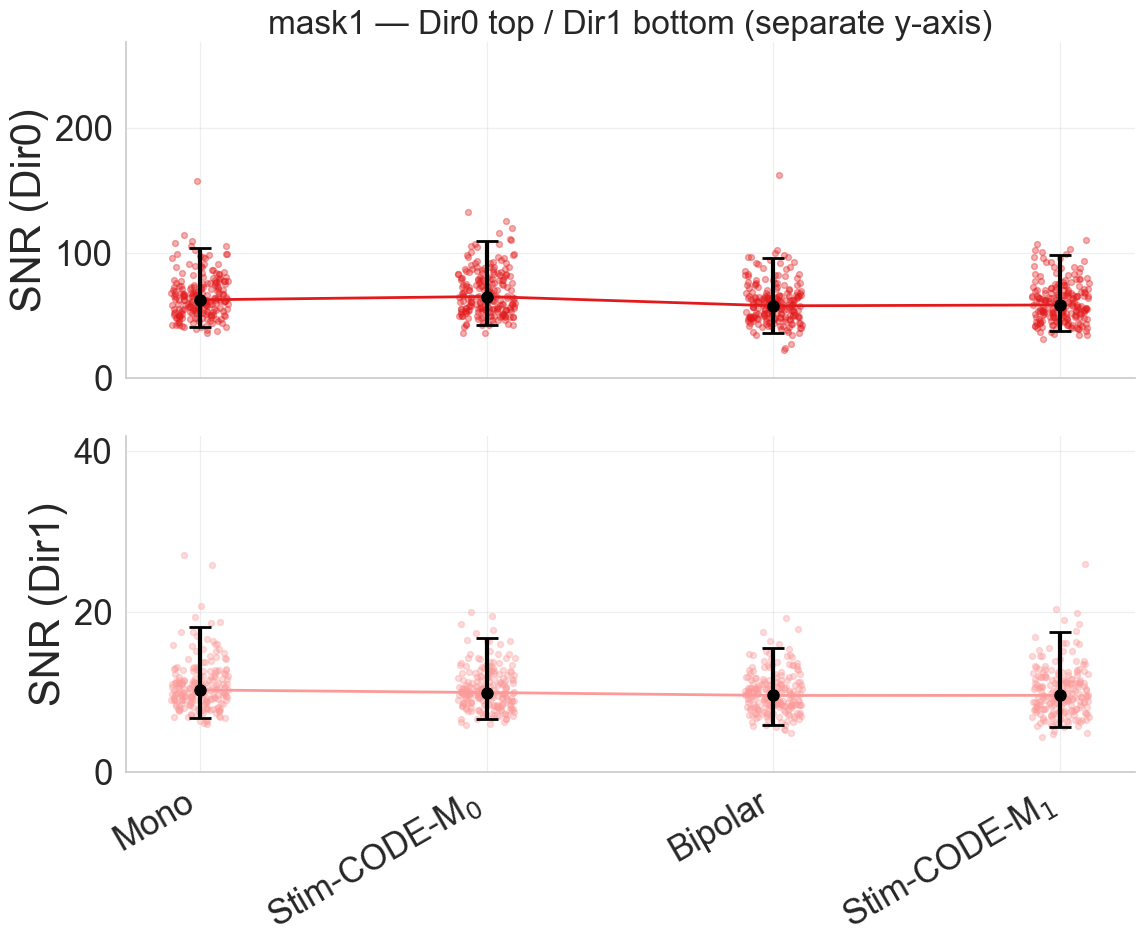

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
ax0, ax1 = axes

dir0_medians = []
dir1_medians = []

for s, scan in enumerate(scan_names):

    # --------------------------
    # Direction 0 (top)
    # --------------------------
    snr_dir0 = phantom_snr[scan][mask_to_plot]['dir0']
    ax0.scatter(
        np.full_like(snr_dir0, xpos[s]) + np.random.uniform(-JITTER, JITTER, len(snr_dir0)),
        snr_dir0,
        s=SCATTER_SIZE, alpha=0.35, color=DIR0_COLOR
    )
    med0, lo0, hi0 = bootstrap_ci(snr_dir0)
    dir0_medians.append(med0)
    ax0.errorbar(
        xpos[s], med0, yerr=[[med0 - lo0],[hi0 - med0]],
        fmt='o', color='black', lw=ERROR_LW, markersize=DOT_SIZE,
        capsize=CAPSIZE, capthick=CAPTHICK, zorder=10
    )

    # --------------------------
    # Direction 1 (bottom)
    # --------------------------
    snr_dir1 = phantom_snr[scan][mask_to_plot]['dir1']
    ax1.scatter(
        np.full_like(snr_dir1, xpos[s]) + np.random.uniform(-JITTER, JITTER, len(snr_dir1)),
        snr_dir1,
        s=SCATTER_SIZE, alpha=0.35, color=DIR1_COLOR
    )
    med1, lo1, hi1 = bootstrap_ci(snr_dir1)
    dir1_medians.append(med1)
    ax1.errorbar(
        xpos[s], med1, yerr=[[med1 - lo1],[hi1 - med1]],
        fmt='o', color='black', lw=ERROR_LW, markersize=DOT_SIZE,
        capsize=CAPSIZE, capthick=CAPTHICK, zorder=10
    )

# Connect medians
ax0.plot(xpos, dir0_medians, color=DIR0_COLOR, lw=2)
ax1.plot(xpos, dir1_medians, color=DIR1_COLOR, lw=2)

# Axis formatting
ax0.set_ylabel('SNR (Dir0)')
ax1.set_ylabel('SNR (Dir1)')
ax1.set_xticks(xpos)
ax1.set_xticklabels(scan_xtick_labels, rotation=30, ha='right')

# Set separate y-limits
ax0.set_ylim(0, 4.1 * np.nanmax(dir0_medians))
ax1.set_ylim(0, 4.1 * np.nanmax(dir1_medians))

# Common styling
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3)

ax0.set_title(f'{mask_to_plot} — Dir0 top / Dir1 bottom (separate y-axis)')

plt.tight_layout()
plt.show()

fig.savefig(f'Fig_SNR_dir0_dir1_separateY_{mask_to_plot}_{phantom_name}.svg', dpi=300, bbox_inches='tight')

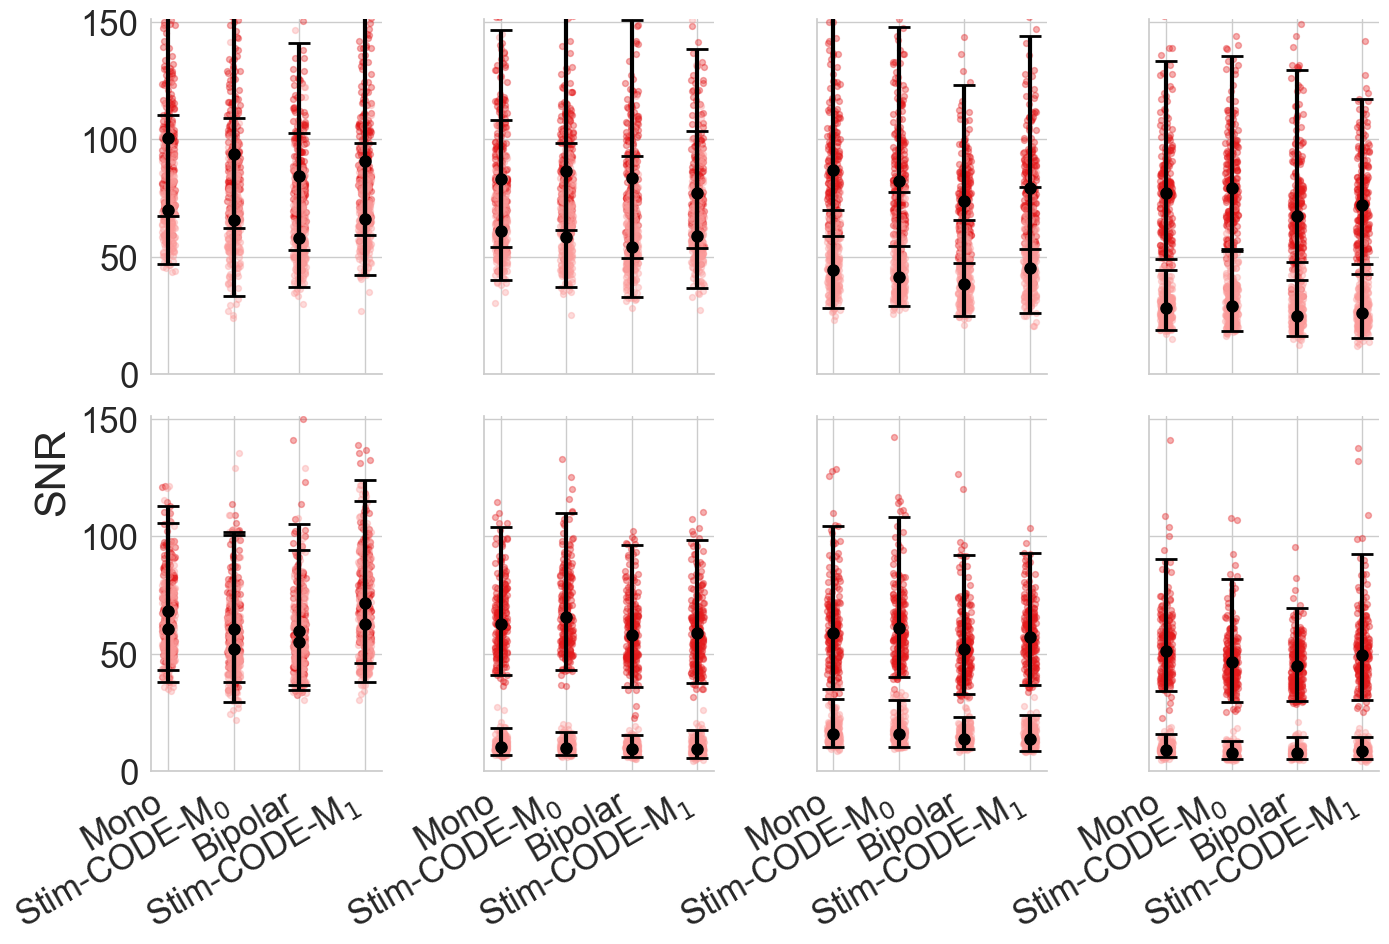

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
# GLOBAL FONT + STYLE CONTROL
# ====================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 30
TICK_FONTSIZE  = 25
SCATTER_SIZE   = 18
DOT_SIZE       = 8
ERROR_LW       = 3.0
CAPSIZE        = 8
CAPTHICK       = 2
JITTER         = 0.10

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})


# ====================================================
# User choices
# ====================================================
phantom_name = 'Phantom_Head'
scan_xtick_labels = [
    'Mono', 'Stim-CODE-M$_0$', 'Bipolar', 'Stim-CODE-M$_1$'
]

mask_names_sorted = sorted(mask_names, key=lambda m: np.nanmedian(
    np.concatenate([phantom_snr[scan][m]['dir0'] for scan in scan_names])
), reverse=True)

n_masks = len(mask_names_sorted)
n_cols  = 4
n_rows  = int(np.ceil(n_masks / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3.6 * n_cols, 5.0 * n_rows),
    sharex=True, sharey=True
)

axes = axes.flatten() if n_masks > 1 else [axes]
xpos = np.arange(len(scan_names))

# ============================================================
# Bootstrap CI function
# ============================================================
def bootstrap_ci(data):
    data = np.array(data)
    N    = data.shape[0]
    Nbs  = 1000
    
    np.random.seed(0)
    bs_idx = np.random.randint(0, N, (N, Nbs))
    bs     = data[bs_idx]

    lower_bound = np.percentile(bs, 2.5, axis = 0).mean()
    upper_bound = np.percentile(bs, 97.5, axis = 0).mean()
    CI_low  = lower_bound
    CI_high = upper_bound
    return [np.nanmedian(data),CI_low, CI_high]
# ====================================================
# Plotting loop
# ====================================================
for ax_idx, mask_name in enumerate(mask_names_sorted):
    ax = axes[ax_idx]

    for s, scan in enumerate(scan_names):

        # --- Direction 0 ---
        snr_dir0 = phantom_snr[scan][mask_name]['dir0']
        ax.scatter(
            np.full_like(snr_dir0, xpos[s]) + np.random.uniform(-JITTER, JITTER, len(snr_dir0)),
            snr_dir0,
            s=SCATTER_SIZE,
            alpha=0.35,
            color=sns.color_palette('Paired',10)[5]
        )
        med, lo, hi = bootstrap_ci(snr_dir0)
        ax.errorbar(
            xpos[s], med,
            yerr=[[med-lo],[hi-med]],
            fmt='o', color='black', lw=ERROR_LW, markersize=DOT_SIZE,
            capsize=CAPSIZE, capthick=CAPTHICK, zorder=10
        )

        # --- Direction 1 ---
        snr_dir1 = phantom_snr[scan][mask_name]['dir1']
        ax.scatter(
            np.full_like(snr_dir1, xpos[s]) + np.random.uniform(-JITTER, JITTER, len(snr_dir1)),
            snr_dir1,
            s=SCATTER_SIZE,
            alpha=0.35,
            color=sns.color_palette('Paired',10)[4]
        )
        med, lo, hi = bootstrap_ci(snr_dir1)
        ax.errorbar(
            xpos[s], med,
            yerr=[[med-lo],[hi-med]],
            fmt='o', color='black', lw=ERROR_LW, markersize=DOT_SIZE,
            capsize=CAPSIZE, capthick=CAPTHICK, zorder=10
        )

    # Axis formatting
    ax.set_xticks(xpos)
    ax.set_xticklabels(scan_xtick_labels, rotation=30, ha='right')
    ax.set_ylim([0, np.nanmax([np.nanmax(phantom_snr[scan][mask_name]['dir0']),
                               np.nanmax(phantom_snr[scan][mask_name]['dir1'])])*1.1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Turn off empty subplots
for i in range(n_masks, n_rows*n_cols):
    fig.delaxes(axes[i])

# Shared y-label
fig.text(0.04, 0.5, 'SNR', va='center', rotation='vertical', fontsize=LABEL_FONTSIZE)

plt.tight_layout(w_pad=-1, h_pad=0.35)
plt.show()

In [ ]:
lo,hi

(4.983883543559272, 14.469485094543558)

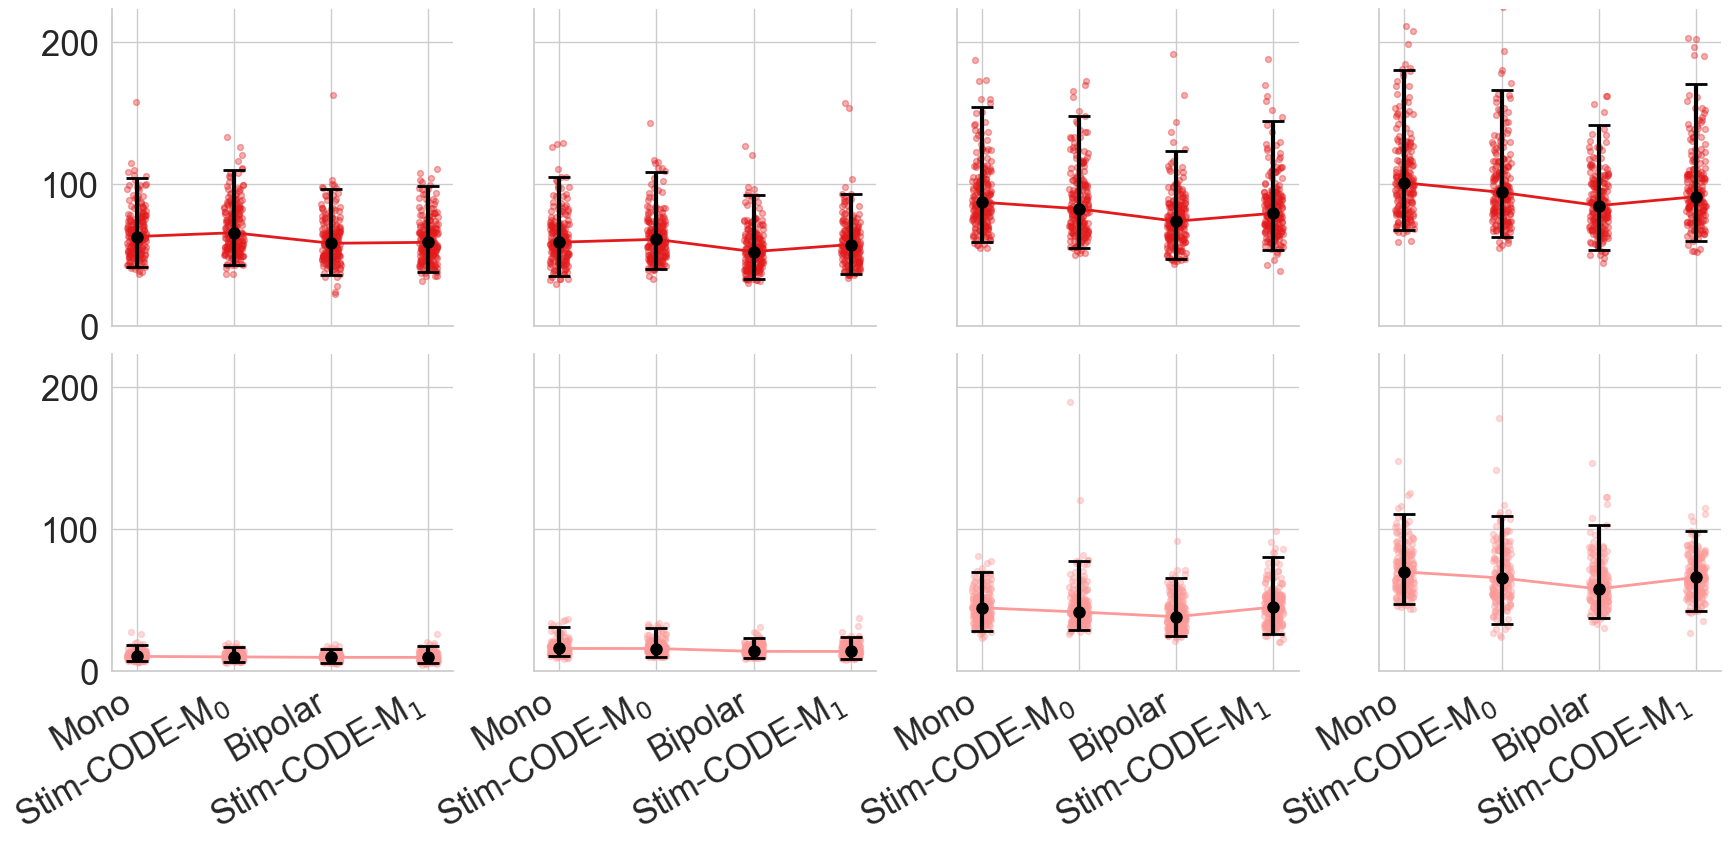

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================
# GLOBAL FONT + STYLE CONTROL
# ====================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 30
TICK_FONTSIZE  = 25
SCATTER_SIZE   = 18
DOT_SIZE       = 8
ERROR_LW       = 3.0
CAPSIZE        = 8
CAPTHICK       = 2
JITTER         = 0.10

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# ====================================================
# User choices
# ====================================================
phantom_name = 'Phantom_Head'
scan_xtick_labels = [
    'Mono', 'Stim-CODE-M$_0$', 'Bipolar', 'Stim-CODE-M$_1$'
]

# Custom mask order
# 'mask1', 'mask3', 'mask4', 'mask5', 'mask6', 'mask7', 'mask8', 'mask2'
mask_order = ['mask1', 'mask4', 'mask6', 'mask8']  # example
n_masks = len(mask_order)
n_cols  = n_masks
n_rows  = 2


fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4.5 * n_cols, 9),
    sharex=True, sharey=True
)

xpos = np.arange(len(scan_names))



# ============================================================
# Bootstrap CI function
# ============================================================
def bootstrap_ci(data):
    data = np.array(data)
    N    = data.shape[0]
    Nbs  = 1000
    np.random.seed(0)
    bs_idx = np.random.randint(0, N, (N, Nbs))
    bs     = data[bs_idx]
    lower_bound = np.percentile(bs, 2.5, axis=0).mean()
    upper_bound = np.percentile(bs, 97.5, axis=0).mean()
    return [np.nanmedian(data), lower_bound, upper_bound]

# ====================================================
# Plotting loop with median lines
# ====================================================
for col, mask_name in enumerate(mask_order):
    for row in range(2):

        ax = axes[row, col]
        direction = 'dir0' if row == 0 else 'dir1'
        color = sns.color_palette('Paired', 10)[5 if row == 0 else 4]

        medians = []

        for s, scan in enumerate(scan_names):
            snr_vals = phantom_snr[scan][mask_name][direction]

            ax.scatter(
                np.full_like(snr_vals, xpos[s]) +
                np.random.uniform(-JITTER, JITTER, len(snr_vals)),
                snr_vals,
                s=SCATTER_SIZE,
                alpha=0.35,
                color=color
            )

            med, lo, hi = bootstrap_ci(snr_vals)
            medians.append(med)

            ax.errorbar(
                xpos[s], med,
                yerr=[[med - lo], [hi - med]],
                fmt='o', color='black',
                lw=ERROR_LW, markersize=DOT_SIZE,
                capsize=CAPSIZE, capthick=CAPTHICK,
                zorder=10
            )

        # Connect medians
        ax.plot(xpos, medians, color=color, lw=2)

        # Axis formatting
        ax.set_xticks(xpos)
        if row == 1:
            ax.set_xticklabels(scan_xtick_labels, rotation=30, ha='right')
        else:
            ax.set_xticklabels([])

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)





# ====================================================
# Set yticks and x-tick labels per row
# ====================================================
for idx, ax in enumerate(axes.flatten()):
    ax.set_xticks(xpos)
    # Only bottom row gets x-tick labels
    if idx // n_cols == n_rows - 1:  # bottom row
        ax.set_xticklabels(scan_xtick_labels, rotation=30, ha='right')
    else:  # top row
        ax.set_xticklabels([])  # hide x-tick labels
    ax.set_ylim([0, np.nanmax([
        np.nanmax(phantom_snr[scan][mask_name]['dir0']),
        np.nanmax(phantom_snr[scan][mask_name]['dir1'])
    ])*1.1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


plt.tight_layout(w_pad=-1., h_pad=0.25)
plt.show()
fig.savefig(f'fig_snr_withlines_{phantom_name}.svg', dpi=300, bbox_inches='tight')

In [ ]:
from itertools import combinations
from scipy.stats import shapiro, wilcoxon, ttest_rel
from statsmodels.stats.multitest import multipletests
import numpy as np

# ------------------------------------------------------------
# Build scan_snr per diff dir
# ------------------------------------------------------------
scan_snr_dir0 = {scan: [] for scan in data_folders}
scan_snr_dir1 = {scan: [] for scan in data_folders}
scan_snr_dir2 = {scan: [] for scan in data_folders}
scan_snr_dir3 = {scan: [] for scan in data_folders}

for volunteer in median_snr_all_vols:
    for i, scan in enumerate(data_folders):
        if i < len(median_snr_all_vols[volunteer]):
            tmp = np.squeeze(median_snr_all_vols[volunteer][i])
            scan_snr_dir0[scan].append(tmp[0])
            scan_snr_dir1[scan].append(tmp[1])
            scan_snr_dir2[scan].append(tmp[2])
            scan_snr_dir3[scan].append(tmp[3])


# ------------------------------------------------------------
# Statistics function
# ------------------------------------------------------------
from itertools import combinations
from scipy.stats import shapiro, friedmanchisquare, wilcoxon, ttest_rel
from statsmodels.stats.multitest import multipletests
import numpy as np

import numpy as np
import pandas as pd
from itertools import combinations
from scipy.stats import shapiro, friedmanchisquare, wilcoxon, ttest_rel
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.anova import AnovaRM

def compute_stats(scan_snr, scans, alpha_global=0.05):
    """
    Perform repeated-measures ANOVA (or Friedman if non-normal) and post-hoc pairwise tests
    only if the global test is significant.

    Parameters
    ----------
    scan_snr : dict
        Keys = scan names, values = list of values per volunteer
    scans : list
        List of scan names (order matters)
    alpha_global : float
        Threshold for global test significance to proceed to post-hoc

    Returns
    -------
    pairs : list of tuples
        Pairs of scans tested (empty if no post-hoc)
    pvals_corr : list
        Holm-corrected p-values for each pair (empty if no post-hoc)
    test_name : str
        Name of global test used
    p_global : float
        p-value of the global test
    """

    # Build subjects × scans matrix
    X = np.array([[scan_snr[scan][i] for scan in scans]
                  for i in range(len(scan_snr[scans[0]]))], dtype=float)
    # Remove subjects with missing values
    X = X[np.all(np.isfinite(X), axis=1)]
    n_subjects, n_conditions = X.shape

    # Convert to long-form DataFrame for AnovaRM
    df = pd.DataFrame(X, columns=scans)
    df['subject'] = np.arange(n_subjects)
    df_long = df.melt(id_vars='subject', value_vars=scans,
                      var_name='condition', value_name='value')

    # ------------------------------------------------------------
    # Global test: repeated-measures ANOVA or Friedman
    # ------------------------------------------------------------
    try:
        # Compute residuals for normality
        residuals = df_long['value'].values - df_long.groupby('subject')['value'].transform('mean').values
        W, p_norm = shapiro(residuals)

        if p_norm > 0.05:
            # Residuals normal → repeated-measures ANOVA
            aovrm = AnovaRM(df_long, 'value', 'subject', within=['condition'])
            res = aovrm.fit()
            p_global = res.anova_table['Pr > F'][0]
            test_name = "Repeated-measures ANOVA"
        else:
            # Residuals non-normal → Friedman test
            stat, p_global = friedmanchisquare(*X.T)
            test_name = "Friedman test"
    except Exception as e:
        print("Global test failed:", e)
        test_name = "Failed"
        p_global = np.nan

    # ------------------------------------------------------------
    # Post-hoc only if global significant
    # ------------------------------------------------------------
    pairs = []
    pvals_corr = []

    if p_global < alpha_global:
        pairs = list(combinations(range(n_conditions), 2))
        pvals = []

        if test_name == "Repeated-measures ANOVA":
            for i, j in pairs:
                _, p = ttest_rel(X[:, i], X[:, j])
                pvals.append(p)
        else:  # Friedman
            for i, j in pairs:
                _, p = wilcoxon(X[:, i], X[:, j])
                pvals.append(p)

        # Holm correction
        _, pvals_corr, _, _ = multipletests(pvals, method='holm')
    
    print(test_name, p_global)
    return pairs, pvals_corr, test_name, p_global
# ------------------------------------------------------------
# Compute for both directions
# ------------------------------------------------------------
pairs0, pvals0, _, _ = compute_stats(scan_snr_dir0, data_folders)
pairs1, pvals1, _, _ = compute_stats(scan_snr_dir1, data_folders)
pairs2, pvals2, _, _ = compute_stats(scan_snr_dir2, data_folders)
pairs3, pvals3, _, _ = compute_stats(scan_snr_dir3, data_folders)

# ------------------------------------------------------------
# Print Results Summary
# ------------------------------------------------------------
def print_stats(pairs, pvals, diff_dir):
    print(f"\nSignificance results for diffusion direction {diff_dir}:")
    for (i, j), p in zip(pairs, pvals):
        signif = "✓" if p < 0.05 else "ns"
        if p < 0.05:
            print(f"{col_labels[i]} vs {col_labels[j]}: p_corr = {p:.4g} ({signif})")
print_stats(pairs0, pvals0, diff_dir=0)
print_stats(pairs1, pvals1, diff_dir=1)
print_stats(pairs2, pvals2, diff_dir=2)
print_stats(pairs3, pvals3, diff_dir=3)

Repeated-measures ANOVA nan
Repeated-measures ANOVA nan
Friedman test 0.3916251762710884
Repeated-measures ANOVA nan

Significance results for diffusion direction 0:

Significance results for diffusion direction 1:

Significance results for diffusion direction 2:

Significance results for diffusion direction 3:


/opt/anaconda3/envs/CarDpy3/lib/python3.8/site-packages/statsmodels/stats/anova.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  mse = ssr / df_resid
/opt/anaconda3/envs/CarDpy3/lib/python3.8/site-packages/statsmodels/stats/anova.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  mse = ssr / df_resid
/opt/anaconda3/envs/CarDpy3/lib/python3.8/site-packages/statsmodels/stats/anova.py:598: RuntimeWarning: divide by zero encountered in scalar divide
  mse = ssr / df_resid


ValueError: 'yerr' must not contain negative values

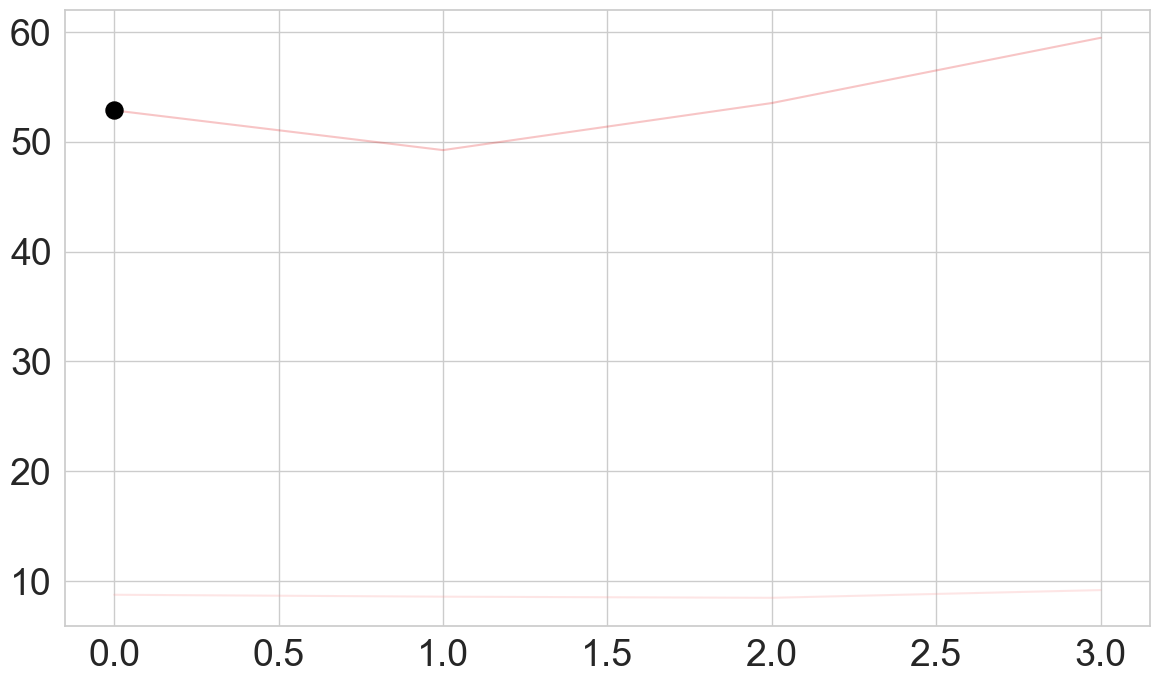

In [ ]:
# ============================================================
# Scatter + point plot of median SNR per scan
# Two diffusion directions on the same axis
# with bootstrapped 95% CI
# + significance brackets (Holm-corrected)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.transforms as mtransforms

# ====================================================
#  GLOBAL FONT + STYLE CONTROL
# ====================================================
TITLE_FONTSIZE = 24
LABEL_FONTSIZE = 28
TICK_FONTSIZE  = 27
SCATTER_SIZE   = 128
MEDIAN_SIZE    = 150
CI_LINEWIDTH   = 4
CI_CAPSIZE     = 10
CI_CAPTHICK    = 3

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
})

# ====================================================
# Diffusion directions to plot
# ====================================================
diff_dirs    = [0, 1]
diff_labels  = ['Dir 0', 'Dir 1']
diff_colors  = [sns.color_palette('Paired',10)[5], sns.color_palette('Paired',10)[4]]   # blue / orange
diff_markers = ['o', 'o']

# ====================================================
# Scan labels
# ====================================================
col_labels = [
    'Mono',
    'Stim-CODE-M$_0$',
    'Bipolar',
    'Stim-CODE-M$_1$',
]

# ====================================================
# Significance helpers
# ====================================================
def p_to_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return None


def add_sig_bracket(ax, x1, x2, y, text, h=0.4, lw=2, text_offset_pts=-35.):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        lw=lw,
        color='black',
        clip_on=False
    )

    trans = ax.transData + mtransforms.ScaledTranslation(
        0, text_offset_pts / 72., ax.figure.dpi_scale_trans
    )

    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha='center',
        va='bottom',
        transform=trans,
        fontsize=TICK_FONTSIZE
    )

# ====================================================
# Plot
# ====================================================
fig, ax = plt.subplots(figsize=(14, 8))
xpos = np.arange(len(data_folders))

# ------------------------------------------------------------
# (1) Paired volunteer trajectories
# ------------------------------------------------------------
for d_idx, diff_dir in enumerate(diff_dirs):
    for volunteer in median_snr_all_vols:
        y_vals, x_vals = [], []

        for i, scan in enumerate(data_folders):
            if i < len(median_snr_all_vols[volunteer]):
                tmp_snr = np.squeeze(median_snr_all_vols[volunteer][i])
                val = tmp_snr[diff_dir]

                if np.isfinite(val):
                    y_vals.append(val)
                    x_vals.append(xpos[i])

        if len(y_vals) > 1:
            ax.plot(
                x_vals,
                y_vals,
                color=diff_colors[d_idx],
                alpha=0.25,
                lw=1.5,
                zorder=1
            )

# ------------------------------------------------------------
# (2) Scatter + bootstrap medians
# ------------------------------------------------------------
for d_idx, diff_dir in enumerate(diff_dirs):

    # Rebuild scan_snr for this diffusion direction
    scan_snr = {scan: [] for scan in data_folders}

    for volunteer in median_snr_all_vols:
        for i, scan in enumerate(data_folders):
            if i < len(median_snr_all_vols[volunteer]):
                tmp_snr = np.squeeze(median_snr_all_vols[volunteer][i])
                scan_snr[scan].append(tmp_snr[diff_dir])

    for i, scan in enumerate(data_folders):
        y = np.asarray(scan_snr[scan], dtype=float)
        y = y[np.isfinite(y)]

        # Scatter
        ax.scatter(
            np.full_like(y, xpos[i]),
            y,
            s=SCATTER_SIZE,
            alpha=0.75,
            color=diff_colors[d_idx],
            marker=diff_markers[d_idx],
            zorder=3,
            label=diff_labels[d_idx] if i == 0 else None
        )

        # Bootstrap CI
        median_val, lo, hi = bootstrap_ci(y)

        ax.errorbar(
            xpos[i],
            median_val,
            yerr=[[median_val - lo], [hi - median_val]],
            fmt=diff_markers[d_idx],
            markersize=np.sqrt(MEDIAN_SIZE),
            lw=CI_LINEWIDTH,
            capsize=CI_CAPSIZE,
            capthick=CI_CAPTHICK,
            color='black',
            zorder=10
        )

        print(
            f"{col_labels[i]:<20s} | {diff_labels[d_idx]:<5s} "
            f"{median_val:6.3f}  [{lo:6.3f}, {hi:6.3f}]"
        )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xticks(xpos)
ax.set_xticklabels(col_labels, rotation=30, ha='right')
ax.set_ylabel('a.u.')
ax.set_ylim([10, 41])
ax.set_yticks(np.arange(0, 41, 10))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.legend(frameon=False, fontsize=TICK_FONTSIZE)

# ------------------------------------------------------------
# Significance annotations
# ------------------------------------------------------------

# --- diff_dir 0 → above points ---
sig_pairs0 = [(i, j, p) for (i, j), p in zip(pairs0, pvals0) if p < 0.05]
if sig_pairs0:
    y_start0 = max([np.median(scan_snr_dir0[scan]) for scan in data_folders]) + 5
    spacing0 = 1.7  # space between successive brackets
    for idx, (i, j, p) in enumerate(sig_pairs0):
        star = p_to_star(p)
        if star is None:
            continue
        y = y_start0 + idx * spacing0
        add_sig_bracket(ax, i, j, y, star, text_offset_pts=-13)

# --- diff_dir 1 → below points, bracket faces up ---
sig_pairs1 = [(i, j, p) for (i, j), p in zip(pairs1, pvals1) if p < 0.05]
if sig_pairs1:
    y_start1 = min([np.median(scan_snr_dir1[scan]) for scan in data_folders]) - 1
    spacing1 = 1.7  # vertical spacing between brackets
    for idx, (i, j, p) in enumerate(sig_pairs1):
        star = p_to_star(p)
        if star is None:
            continue
        y = y_start1 - idx * spacing1
        add_sig_bracket(ax, i, j, y, star, h=-0.4, text_offset_pts=-13)  # h<0 flips bracket
# ------------------------------------------------------------
# Finalize
# ------------------------------------------------------------
plt.tight_layout()
plt.show()

fig.savefig(
    'fig_snr_median_allvols_diffdir01.svg',
    dpi=300,
    bbox_inches='tight'
)

In [ ]:
pvals_corr

array([0.76953125, 0.01171875, 0.01171875, 0.01171875, 0.01171875,
       0.01171875])

In [ ]:
0.25 * 9

2.25

In [ ]:
0.05*12

0.6000000000000001

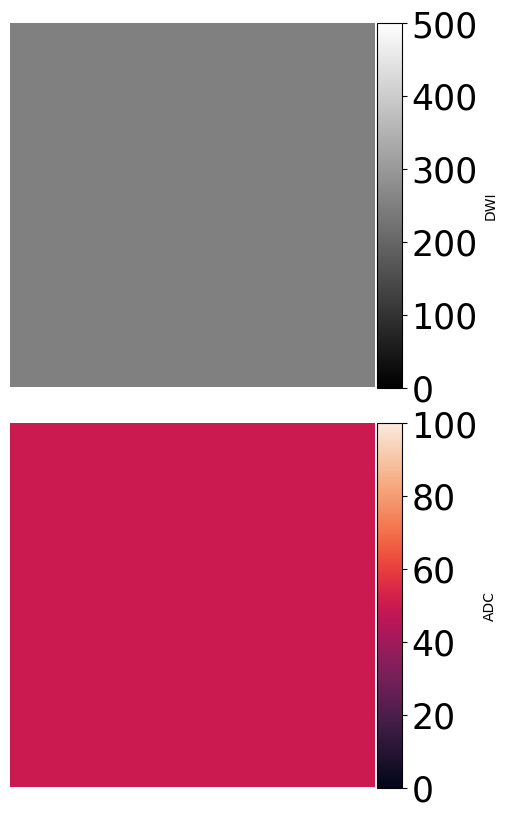

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ------------------------
# Dummy images for colorbars
# ------------------------
dwi_img_dummy = np.ones((1, 1)) * (dwi_vmin + dwi_vmax) / 2
snr_img_dummy = np.ones((1, 1)) * (snr_vmin + snr_vmax) / 2

# ------------------------
# Stack into one figure
# ------------------------
fig, axs = plt.subplots(2, 1, figsize=(4, 8), constrained_layout=True)

# Control thickness and padding
cbar_width = 0.25  # fraction of axis width
cbar_pad   = 0.02

# Tick font size
cbar_tick_fs = 25

# Row 0: DWI
im0 = axs[0].imshow(dwi_img_dummy, cmap='gray', vmin=dwi_vmin, vmax=dwi_vmax)
axs[0].axis('off')
divider0 = make_axes_locatable(axs[0])
cax0 = divider0.append_axes("right", size=cbar_width, pad=cbar_pad)
cb0 = fig.colorbar(im0, cax=cax0, label='DWI')
cb0.ax.tick_params(labelsize=cbar_tick_fs)

# Row 1: ADC
im1 = axs[1].imshow(snr_img_dummy, cmap=rocket_cmap, vmin=snr_vmin, vmax=snr_vmax)
axs[1].axis('off')
divider1 = make_axes_locatable(axs[1])
cax1 = divider1.append_axes("right", size=cbar_width, pad=cbar_pad)
cb1 = fig.colorbar(im1, cax=cax1, label='ADC')
cb1.ax.tick_params(labelsize=cbar_tick_fs)



plt.show()
fig.savefig('stacked_colorbars_thick_ticks.svg', dpi=300, bbox_inches='tight')